In [1]:
import pandas as pd 
a=pd.read_csv(r"C:\Users\subhadip sinha\OneDrive\CODING\PYTHON\Scikit-Learn\titanic dataset.csv")
a

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
aa=a.select_dtypes(include="object")
new_ob=aa.keys()


bb=a.select_dtypes(include=["float64","int64"])
new_in=bb.keys()

In [4]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy="most_frequent")
s=si.fit_transform(a[new_ob])
f=pd.DataFrame(s,columns=[new_ob])
f

,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,B96 B98,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,B96 B98,S
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,113803,C123,S
4,"Allen, Mr. William Henry",male,373450,B96 B98,S
...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,211536,B96 B98,S
887,"Graham, Miss. Margaret Edith",female,112053,B42,S
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,W./C. 6607,B96 B98,S
889,"Behr, Mr. Karl Howell",male,111369,C148,C


In [5]:
z=si.fit_transform(a[new_in])
k=pd.DataFrame(z,columns=[new_in])
k

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1.0,0.0,3.0,22.0,1.0,0.0,7.2500
1,2.0,1.0,1.0,38.0,1.0,0.0,71.2833
2,3.0,1.0,3.0,26.0,0.0,0.0,7.9250
3,4.0,1.0,1.0,35.0,1.0,0.0,53.1000
4,5.0,0.0,3.0,35.0,0.0,0.0,8.0500
...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,27.0,0.0,0.0,13.0000
887,888.0,1.0,1.0,19.0,0.0,0.0,30.0000
888,889.0,0.0,3.0,24.0,1.0,2.0,23.4500
889,890.0,1.0,1.0,26.0,0.0,0.0,30.0000


In [6]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
e=oe.fit_transform(f)
ne=pd.DataFrame(e,columns=[new_ob])
ne

,Name,Sex,Ticket,Cabin,Embarked
0,108.0,1.0,523.0,47.0,2.0
1,190.0,0.0,596.0,81.0,0.0
2,353.0,0.0,669.0,47.0,2.0
3,272.0,0.0,49.0,55.0,2.0
4,15.0,1.0,472.0,47.0,2.0
...,...,...,...,...,...
886,548.0,1.0,101.0,47.0,2.0
887,303.0,0.0,14.0,30.0,2.0
888,413.0,0.0,675.0,47.0,2.0
889,81.0,1.0,8.0,60.0,0.0


In [7]:
a["Name"]=ne["Name"]
a["Sex"]=ne["Sex"]
a["Ticket"]=ne["Ticket"]
a["Cabin"]=ne["Embarked"]
a["Embarked"]=ne["Embarked"]
a["PassengerId"]=k["PassengerId"]
a["Survived"]=k["Survived"]
a["Pclass"]=k["Pclass"]
a["Age"]=k["Age"]
a["SibSp"]=k["SibSp"]
a["Parch"]=k["Parch"]
a["Fare"]=k["Fare"]

In [8]:
a

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1.0,0.0,3.0,108.0,1.0,22.0,1.0,0.0,523.0,7.2500,2.0,2.0
1,2.0,1.0,1.0,190.0,0.0,38.0,1.0,0.0,596.0,71.2833,0.0,0.0
2,3.0,1.0,3.0,353.0,0.0,26.0,0.0,0.0,669.0,7.9250,2.0,2.0
3,4.0,1.0,1.0,272.0,0.0,35.0,1.0,0.0,49.0,53.1000,2.0,2.0
4,5.0,0.0,3.0,15.0,1.0,35.0,0.0,0.0,472.0,8.0500,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887.0,0.0,2.0,548.0,1.0,27.0,0.0,0.0,101.0,13.0000,2.0,2.0
887,888.0,1.0,1.0,303.0,0.0,19.0,0.0,0.0,14.0,30.0000,2.0,2.0
888,889.0,0.0,3.0,413.0,0.0,24.0,1.0,2.0,675.0,23.4500,2.0,2.0
889,890.0,1.0,1.0,81.0,1.0,26.0,0.0,0.0,8.0,30.0000,0.0,0.0


In [9]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    float64
 1   Survived     891 non-null    float64
 2   Pclass       891 non-null    float64
 3   Name         891 non-null    float64
 4   Sex          891 non-null    float64
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    float64
 7   Parch        891 non-null    float64
 8   Ticket       891 non-null    float64
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    float64
 11  Embarked     891 non-null    float64
dtypes: float64(12)
memory usage: 83.7 KB


In [10]:
a.describe()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,445.000000,0.647587,28.566970,0.523008,0.381594,338.528620,32.204208,1.536476,1.536476
std,257.353842,0.486592,0.836071,257.353842,0.477990,13.199572,1.102743,0.806057,200.850657,49.693429,0.791503,0.791503
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,222.500000,0.000000,22.000000,0.000000,0.000000,158.500000,7.910400,1.000000,1.000000
50%,446.000000,0.000000,3.000000,445.000000,1.000000,24.000000,0.000000,0.000000,337.000000,14.454200,2.000000,2.000000
75%,668.500000,1.000000,3.000000,667.500000,1.000000,35.000000,1.000000,0.000000,519.500000,31.000000,2.000000,2.000000
max,891.000000,1.000000,3.000000,890.000000,1.000000,80.000000,8.000000,6.000000,680.000000,512.329200,2.000000,2.000000


C:\Users\subhadip sinha\AppData\Local\Temp\ipykernel_24800\1793187843.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y)


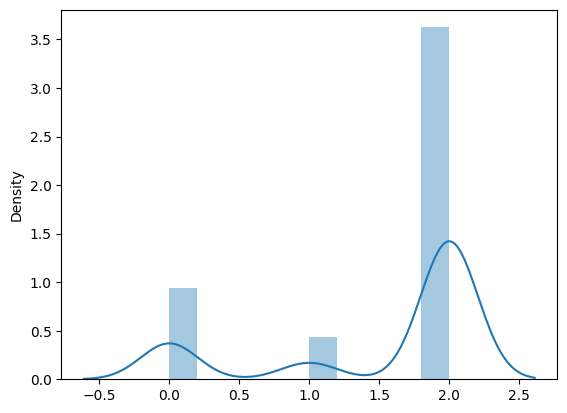

In [ ]:
x=a.iloc[:,:-1]
y=a.iloc[:,-1:]

import matplotlib.pyplot as plt
import seaborn as sns
sns.distplot(y)

plt.show()

In [12]:
from sklearn.model_selection import train_test_split
x_tarin,x_test,y_tarin,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [13]:
from sklearn.naive_bayes import GaussianNB

gnb=GaussianNB()
gnb.fit(x_tarin,y_tarin)
gnb.score(x_test,y_test)*100

d:\PYTHON_environment\ENV2\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


100.0

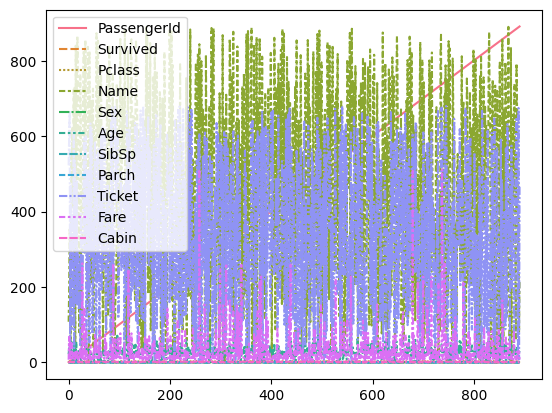

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x)
plt.show()

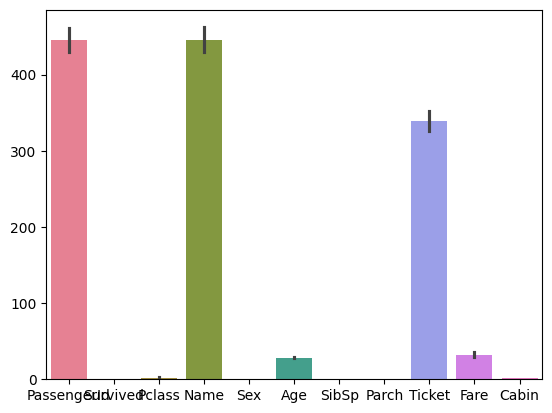

In [15]:
sns.barplot(x)
plt.show()

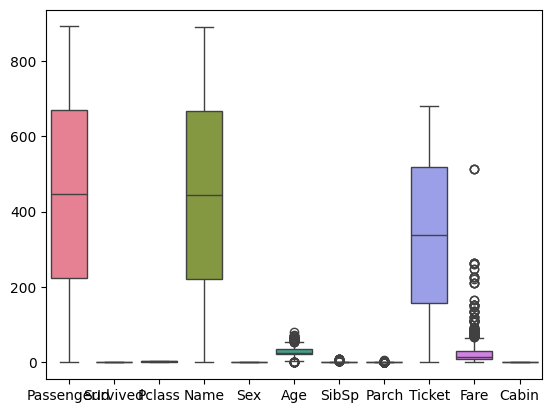

In [16]:
sns.boxplot(x)
plt.show()